<a href="https://colab.research.google.com/github/Akshid-S/FocusFlow/blob/main/mall_customercluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.environ['KAGGLE_USERNAME']="akshidbaskars"
os.environ['KAGGLE_KEY']="KGAT_719126a55683f913756820acd15f97ad"


In [1]:
!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python

Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
100% 1.55k/1.55k [00:00<00:00, 557kB/s]



In [2]:
import zipfile
import os

zip_path = "/content/customer-segmentation-tutorial-in-python.zip"
extract_path = "/content/extracted_files"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully!")

Files extracted successfully!


In [3]:
# ==========================================
# HIERARCHICAL CLUSTERING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

import zipfile
import os

In [4]:
data=pd.read_csv("/content/extracted_files/Mall_Customers.csv")
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [11]:
print("Rows: ",data.shape[0])
print("Columns: ",data.shape[1])




Rows:  200
Columns:  5


In [13]:
data.isnull().sum()



,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [15]:
print("Duplicated Rows:",data.duplicated().sum())

Duplicated Rows: 0


In [16]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [18]:
X=data[['CustomerID','Age'] ]
X.head()

,CustomerID,Age
0,1,19
1,2,21
2,3,20
3,4,23
4,5,31


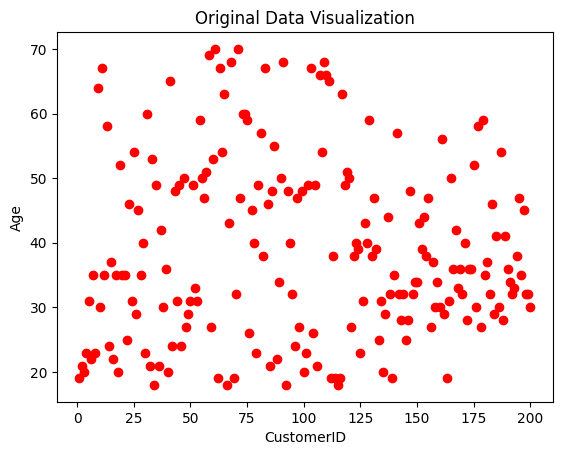

In [20]:
# Step 11: Original Data Visualization
plt.Figure(figsize=(10,8))
plt.scatter(X['CustomerID'], X['Age'],color='red')

plt.xlabel('CustomerID')
plt.ylabel('Age')
plt.title('Original Data Visualization')
plt.show()

In [21]:
# Step 12: Feature Scaling
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

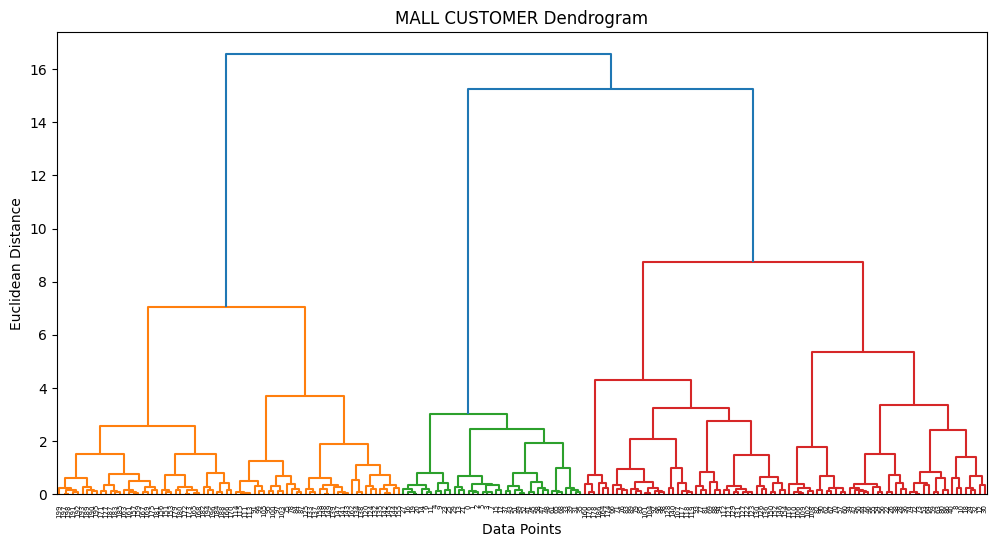

In [22]:
# Step 13: Dendrogram
linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("MALL CUSTOMER Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Euclidean Distance")

plt.show()


In [23]:
# ==========================================
# Step 14: Train Model
# ==========================================

hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

In [24]:
data["Cluster"] = clusters

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [25]:
print(data["Cluster"].value_counts())

Cluster
0    87
1    74
2    39
Name: count, dtype: int64


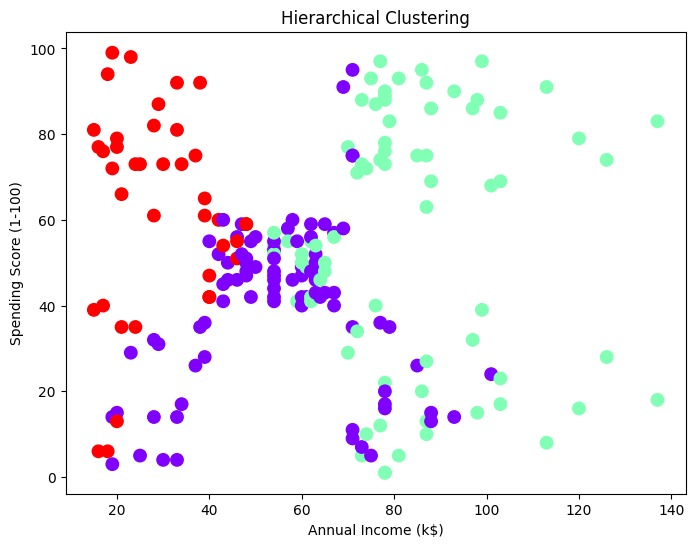

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    data["Annual Income (k$)"],
    data["Spending Score (1-100)"],
    c=data["Cluster"],
    cmap="rainbow",
    s=80
)

plt.title("Hierarchical Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [33]:
data.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,88.770115,51.620690,55.413793,40.183908
1,152.000000,30.351351,83.270270,55.324324
2,28.948718,26.487179,28.948718,62.820513
